# Deep Learning Lab Minor Project on CVC-ClinicDB

This notebook implements the tasks from the project PDF using the local **CVC-ClinicDB** dataset.

**Task mapping used here**
- Classification target: `sequence_id` from `metadata.csv` (used as class label)
- Imbalance handling: under-sampling and augmentation-based over-sampling on training split
- Transfer learning models: EfficientNet-B0, MobileNetV3-Large, ConvNeXt-Tiny
- Intelligent LR control: `ReduceLROnPlateau`
- Evaluation: Accuracy, Precision, Recall, F1-score, confusion matrix

## 0. Setup
If needed, install dependencies once:
`pip install torch torchvision scikit-learn pandas matplotlib seaborn pillow`

In [1]:
import os
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', DEVICE)

Device: cuda


In [2]:
# Local paths (change only if your folder names differ)
PROJECT_ROOT = Path.cwd()
DATA_ROOT = PROJECT_ROOT / 'CVC-ClinicDB (Related GI Endoscopy)'
META_PATH = DATA_ROOT / 'metadata.csv'

assert META_PATH.exists(), f'metadata.csv not found at: {META_PATH}'
df = pd.read_csv(META_PATH)

# Build full image path from metadata
df['image_path'] = df['png_image_path'].str.replace('PNG/', 'PNG/', regex=False).apply(lambda x: str(DATA_ROOT / x))
df['mask_path'] = df['png_mask_path'].str.replace('PNG/', 'PNG/', regex=False).apply(lambda x: str(DATA_ROOT / x))

# Keep only rows whose files exist
df = df[df['image_path'].apply(os.path.exists)].copy()
df = df[df['mask_path'].apply(os.path.exists)].copy()

# Classification label used in this notebook
df['label_raw'] = df['sequence_id'].astype(str)

print('Total samples:', len(df))
print('Unique classes (sequence_id):', df['label_raw'].nunique())
df.head()

Total samples: 612
Unique classes (sequence_id): 29


,frame_id,sequence_id,tif_image_path,tif_mask_path,png_image_path,png_mask_path,image_path,mask_path,label_raw
0,1,1,TIFF/Original/1.tif,TIFF/Ground Truth/1.tif,PNG/Original/1.png,PNG/Ground Truth/1.png,c:\new pc\College Labs VI\DL lab\Deep-Learning...,c:\new pc\College Labs VI\DL lab\Deep-Learning...,1
1,10,1,TIFF/Original/10.tif,TIFF/Ground Truth/10.tif,PNG/Original/10.png,PNG/Ground Truth/10.png,c:\new pc\College Labs VI\DL lab\Deep-Learning...,c:\new pc\College Labs VI\DL lab\Deep-Learning...,1
2,100,5,TIFF/Original/100.tif,TIFF/Ground Truth/100.tif,PNG/Original/100.png,PNG/Ground Truth/100.png,c:\new pc\College Labs VI\DL lab\Deep-Learning...,c:\new pc\College Labs VI\DL lab\Deep-Learning...,5
3,101,5,TIFF/Original/101.tif,TIFF/Ground Truth/101.tif,PNG/Original/101.png,PNG/Ground Truth/101.png,c:\new pc\College Labs VI\DL lab\Deep-Learning...,c:\new pc\College Labs VI\DL lab\Deep-Learning...,5
4,102,5,TIFF/Original/102.tif,TIFF/Ground Truth/102.tif,PNG/Original/102.png,PNG/Ground Truth/102.png,c:\new pc\College Labs VI\DL lab\Deep-Learning...,c:\new pc\College Labs VI\DL lab\Deep-Learning...,5


## 1. Task 1: Dataset Exploration and Imbalance Analysis

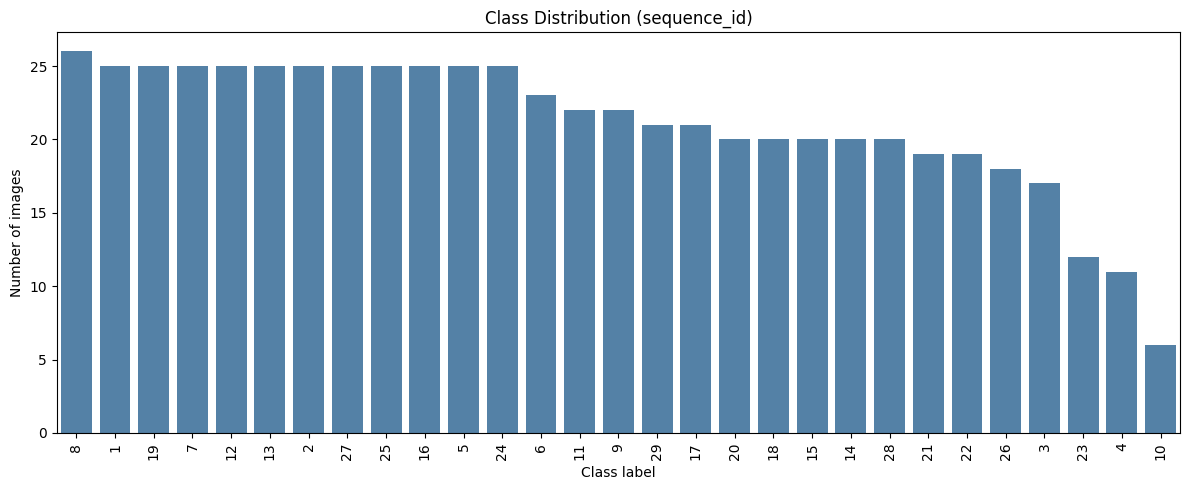

Majority class: 8 -> 26
Minority class: 10 -> 6
Imbalance ratio (max/min): 4.33


In [3]:
class_counts = df['label_raw'].value_counts().sort_values(ascending=False)

plt.figure(figsize=(12, 5))
sns.barplot(x=class_counts.index, y=class_counts.values, color='steelblue')
plt.title('Class Distribution (sequence_id)')
plt.xlabel('Class label')
plt.ylabel('Number of images')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

majority_class = class_counts.idxmax()
minority_class = class_counts.idxmin()
print('Majority class:', majority_class, '->', class_counts.max())
print('Minority class:', minority_class, '->', class_counts.min())
print('Imbalance ratio (max/min):', round(class_counts.max() / class_counts.min(), 2))

**Short explanation (Task 1 deliverable)**

Class imbalance means some classes dominate training while rare classes are under-represented.
In medical AI, this is risky because models may learn to predict frequent findings and miss rare but clinically important cases.
This causes inflated overall accuracy but poor minority-class recall.
To control this, we apply under-sampling of majority classes and over-sampling of minority classes with augmentation.
This improves class balance and stabilizes model learning across all classes.

## 2. Task 4: Data Pre-processing and Split (70/15/15)

In [4]:
# Optional: remove classes with very low samples (helps stable stratified split)
MIN_SAMPLES_PER_CLASS = 5
valid_classes = class_counts[class_counts >= MIN_SAMPLES_PER_CLASS].index
df_filtered = df[df['label_raw'].isin(valid_classes)].copy()

# Encode labels to integer ids
label_names = sorted(df_filtered['label_raw'].unique())
label_to_idx = {c: i for i, c in enumerate(label_names)}
idx_to_label = {i: c for c, i in label_to_idx.items()}
df_filtered['label'] = df_filtered['label_raw'].map(label_to_idx)

train_df, temp_df = train_test_split(
    df_filtered,
    test_size=0.30,
    random_state=SEED,
    stratify=df_filtered['label']
)
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=SEED,
    stratify=temp_df['label']
)

print('Train:', len(train_df), 'Val:', len(val_df), 'Test:', len(test_df))
print('Num classes:', len(label_names))

Train: 428 Val: 92 Test: 92
Num classes: 29


## 3. Task 2: Under-Sampling (Majority Class Control)

In [5]:
def undersample_to_threshold(dataframe, label_col='label', threshold=20, seed=42):
    sampled_parts = []
    rng = np.random.default_rng(seed)
    for cls, grp in dataframe.groupby(label_col):
        if len(grp) > threshold:
            idx = rng.choice(grp.index.values, size=threshold, replace=False)
            sampled_parts.append(grp.loc[idx])
        else:
            sampled_parts.append(grp)
    out = pd.concat(sampled_parts).sample(frac=1.0, random_state=seed).reset_index(drop=True)
    return out

train_counts = train_df['label'].value_counts()
UNDER_THRESHOLD = int(np.median(train_counts.values))
train_under_df = undersample_to_threshold(train_df, threshold=UNDER_THRESHOLD, seed=SEED)

print('Under-sampling threshold:', UNDER_THRESHOLD)
print('Original train size:', len(train_df))
print('Under-sampled train size:', len(train_under_df))

Under-sampling threshold: 15
Original train size: 428
Under-sampled train size: 396


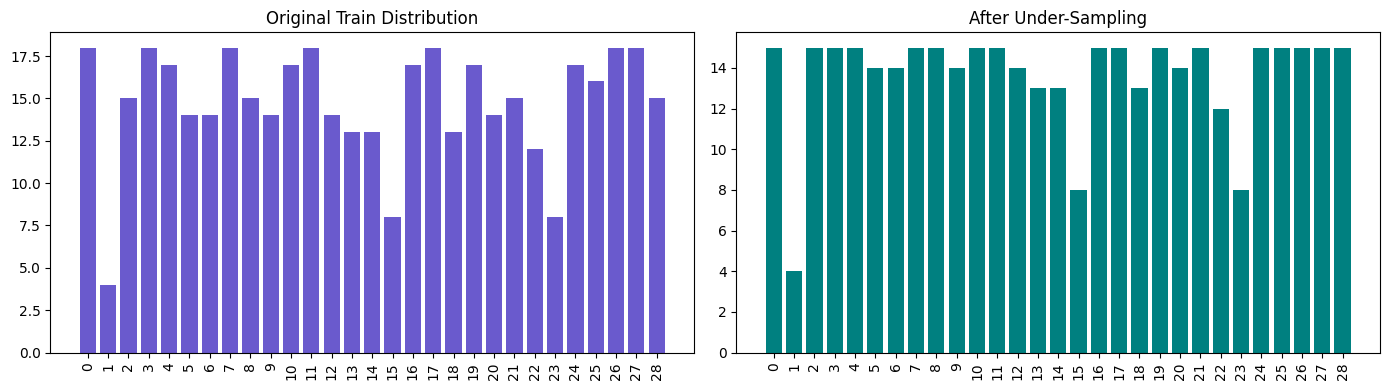

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

orig_counts = train_df['label'].value_counts().sort_index()
under_counts = train_under_df['label'].value_counts().sort_index()

axes[0].bar(orig_counts.index.astype(str), orig_counts.values, color='slateblue')
axes[0].set_title('Original Train Distribution')
axes[0].tick_params(axis='x', rotation=90)

axes[1].bar(under_counts.index.astype(str), under_counts.values, color='teal')
axes[1].set_title('After Under-Sampling')
axes[1].tick_params(axis='x', rotation=90)

plt.tight_layout()
plt.show()

**Observation (Task 2 deliverable):** Under-sampling reduces bias toward majority classes, but removes potentially useful data from frequent classes.

## 4. Task 3: Augmentation-Based Over-Sampling (Minority Classes)

In [7]:
def oversample_with_augmentation_flags(dataframe, label_col='label', target_per_class=20, seed=42):
    rng = np.random.default_rng(seed)
    parts = []
    for cls, grp in dataframe.groupby(label_col):
        grp = grp.copy()
        grp['augment'] = False
        parts.append(grp)

        deficit = target_per_class - len(grp)
        if deficit > 0:
            idx = rng.choice(grp.index.values, size=deficit, replace=True)
            extra = grp.loc[idx].copy()
            extra['augment'] = True
            parts.append(extra)

    out = pd.concat(parts).sample(frac=1.0, random_state=seed).reset_index(drop=True)
    return out

train_under_over_df = oversample_with_augmentation_flags(
    train_under_df,
    target_per_class=UNDER_THRESHOLD,
    seed=SEED
)

print('Under + Over train size:', len(train_under_over_df))
print('Augmented rows:', int(train_under_over_df['augment'].sum()))

Under + Over train size: 435
Augmented rows: 39


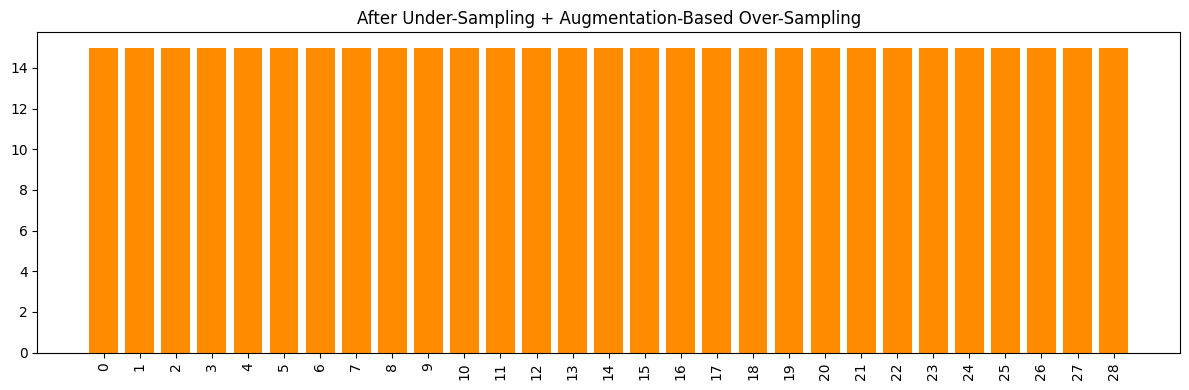

,Original Train,Under-Sampled,Under+Over
label,,,
0,18,15,15
1,4,4,15
2,15,15,15
3,18,15,15
4,17,15,15
5,14,14,15
6,14,14,15
7,18,15,15
8,15,15,15


In [8]:
uo_counts = train_under_over_df['label'].value_counts().sort_index()

plt.figure(figsize=(12, 4))
plt.bar(uo_counts.index.astype(str), uo_counts.values, color='darkorange')
plt.title('After Under-Sampling + Augmentation-Based Over-Sampling')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

summary_df = pd.DataFrame({
    'Original Train': train_df['label'].value_counts().sort_index(),
    'Under-Sampled': train_under_df['label'].value_counts().sort_index(),
    'Under+Over': train_under_over_df['label'].value_counts().sort_index(),
}).fillna(0).astype(int)
summary_df

## 5. Dataset Class and Transforms (224x224, normalization)

In [9]:
IMG_SIZE = 224
BATCH_SIZE = 16
NUM_WORKERS = 0

base_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

augment_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(20),
    transforms.RandomAffine(degrees=0, translate=(0.2, 0.2), scale=(0.8, 1.2)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

class CVCSequenceDataset(Dataset):
    def __init__(self, dataframe, use_augment_flags=False):
        self.df = dataframe.reset_index(drop=True).copy()
        if 'augment' not in self.df.columns:
            self.df['augment'] = False
        self.use_augment_flags = use_augment_flags

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image = Image.open(row['image_path']).convert('RGB')

        if self.use_augment_flags and bool(row['augment']):
            x = augment_transform(image)
        else:
            x = base_transform(image)

        y = int(row['label'])
        return x, y

def make_loaders(train_data, val_data, test_data, use_aug_flags=False):
    train_ds = CVCSequenceDataset(train_data, use_augment_flags=use_aug_flags)
    val_ds = CVCSequenceDataset(val_data, use_augment_flags=False)
    test_ds = CVCSequenceDataset(test_data, use_augment_flags=False)

    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
    val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
    test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
    return train_loader, val_loader, test_loader

## 6. Task 5: Transfer Learning Model Design (3 Models)

In [10]:
def build_model(model_name, num_classes, dropout=0.3):
    if model_name == 'efficientnet_b0':
        model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)
        for p in model.features.parameters():
            p.requires_grad = False
        in_features = model.classifier[-1].in_features
        model.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(in_features, num_classes)
        )

    elif model_name == 'mobilenet_v3_large':
        model = models.mobilenet_v3_large(weights=models.MobileNet_V3_Large_Weights.DEFAULT)
        for p in model.features.parameters():
            p.requires_grad = False
        in_features = model.classifier[-1].in_features
        model.classifier = nn.Sequential(
            nn.Linear(model.classifier[0].in_features, 1024),
            nn.Hardswish(inplace=True),
            nn.Dropout(p=dropout, inplace=False),
            nn.Linear(1024, num_classes)
        )

    elif model_name == 'convnext_tiny':
        model = models.convnext_tiny(weights=models.ConvNeXt_Tiny_Weights.DEFAULT)
        for p in model.features.parameters():
            p.requires_grad = False
        in_features = model.classifier[2].in_features
        model.classifier = nn.Sequential(
            model.classifier[0],
            model.classifier[1],
            nn.Dropout(dropout),
            nn.Linear(in_features, num_classes)
        )

    else:
        raise ValueError(f'Unknown model: {model_name}')

    return model

def count_params(model):
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    frozen = sum(p.numel() for p in model.parameters() if not p.requires_grad)
    return trainable, frozen

NUM_CLASSES = len(label_names)
for name in ['efficientnet_b0', 'mobilenet_v3_large', 'convnext_tiny']:
    m = build_model(name, NUM_CLASSES)
    tr, fr = count_params(m)
    print(f'{name}: trainable={tr:,}, frozen={fr:,}')

efficientnet_b0: trainable=37,149, frozen=4,007,548
mobilenet_v3_large: trainable=1,013,789, frozen=2,971,952
convnext_tiny: trainable=23,837, frozen=27,818,592


## 7. Task 6: Training Utilities with Intelligent LR Control

In [11]:
def run_epoch(model, loader, criterion, optimizer=None):
    is_train = optimizer is not None
    model.train(is_train)

    total_loss = 0.0
    y_true, y_pred = [], []

    for xb, yb in loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)

        if is_train:
            optimizer.zero_grad()

        logits = model(xb)
        loss = criterion(logits, yb)

        if is_train:
            loss.backward()
            optimizer.step()

        total_loss += loss.item() * xb.size(0)
        preds = torch.argmax(logits, dim=1)
        y_true.extend(yb.detach().cpu().numpy().tolist())
        y_pred.extend(preds.detach().cpu().numpy().tolist())

    avg_loss = total_loss / len(loader.dataset)
    acc = accuracy_score(y_true, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average='weighted', zero_division=0
    )
    return avg_loss, acc, precision, recall, f1, y_true, y_pred

def train_model(model_name, train_loader, val_loader, num_classes, epochs=8, lr=1e-3, weight_decay=1e-4):
    model = build_model(model_name, num_classes).to(DEVICE)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.AdamW(
        [p for p in model.parameters() if p.requires_grad],
        lr=lr,
        weight_decay=weight_decay
    )
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=2, min_lr=1e-6
    )

    history = {
        'train_loss': [], 'val_loss': [],
        'train_f1': [], 'val_f1': [],
        'lr': []
    }

    best_state = None
    best_val_f1 = -1

    for epoch in range(1, epochs + 1):
        tr_loss, _, _, _, tr_f1, _, _ = run_epoch(model, train_loader, criterion, optimizer)
        va_loss, _, _, _, va_f1, _, _ = run_epoch(model, val_loader, criterion, optimizer=None)

        scheduler.step(va_loss)
        current_lr = optimizer.param_groups[0]['lr']

        history['train_loss'].append(tr_loss)
        history['val_loss'].append(va_loss)
        history['train_f1'].append(tr_f1)
        history['val_f1'].append(va_f1)
        history['lr'].append(current_lr)

        if va_f1 > best_val_f1:
            best_val_f1 = va_f1
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

        print(f'[{model_name}] Epoch {epoch:02d}/{epochs} | Train Loss {tr_loss:.4f} | Val Loss {va_loss:.4f} | Val F1 {va_f1:.4f} | LR {current_lr:.6f}')

    if best_state is not None:
        model.load_state_dict(best_state)

    return model, history

## 8. Task 7: Train Under Three Settings and Evaluate

In [ ]:
EPOCHS = 8
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4
RUN_FULL_EXPERIMENT = True  

settings = {
    'no_imbalance_handling': (train_df.assign(augment=False), False),
    'under_sampling_only': (train_under_df.assign(augment=False), False),
    'under_plus_augmentation': (train_under_over_df, True),
}

model_names = ['efficientnet_b0', 'mobilenet_v3_large', 'convnext_tiny']
results = []
artifacts = {}

if RUN_FULL_EXPERIMENT:
    for setting_name, (train_data, use_aug_flags) in settings.items():
        print('\n' + '=' * 80)
        print('Setting:', setting_name)

        train_loader, val_loader, test_loader = make_loaders(
            train_data, val_df.assign(augment=False), test_df.assign(augment=False), use_aug_flags=use_aug_flags
        )

        for model_name in model_names:
            model, history = train_model(
                model_name,
                train_loader,
                val_loader,
                num_classes=NUM_CLASSES,
                epochs=EPOCHS,
                lr=LEARNING_RATE,
                weight_decay=WEIGHT_DECAY
            )

            criterion = nn.CrossEntropyLoss()
            te_loss, te_acc, te_prec, te_rec, te_f1, y_true, y_pred = run_epoch(model, test_loader, criterion, optimizer=None)
            cm = confusion_matrix(y_true, y_pred, labels=list(range(NUM_CLASSES)))

            key = (setting_name, model_name)
            artifacts[key] = {'history': history, 'cm': cm, 'y_true': y_true, 'y_pred': y_pred}

            results.append({
                'setting': setting_name,
                'model': model_name,
                'test_loss': te_loss,
                'accuracy': te_acc,
                'precision': te_prec,
                'recall': te_rec,
                'f1_score': te_f1
            })

results_df = pd.DataFrame(results)
results_df


Setting: no_imbalance_handling
[efficientnet_b0] Epoch 01/8 | Train Loss 3.0881 | Val Loss 2.4052 | Val F1 0.7007 | LR 0.001000
[efficientnet_b0] Epoch 02/8 | Train Loss 2.0267 | Val Loss 1.6139 | Val F1 0.8620 | LR 0.001000
[efficientnet_b0] Epoch 03/8 | Train Loss 1.3274 | Val Loss 1.1230 | Val F1 0.9082 | LR 0.001000
[efficientnet_b0] Epoch 04/8 | Train Loss 0.9359 | Val Loss 0.8275 | Val F1 0.9313 | LR 0.001000
[efficientnet_b0] Epoch 05/8 | Train Loss 0.7050 | Val Loss 0.6827 | Val F1 0.9773 | LR 0.001000
[efficientnet_b0] Epoch 06/8 | Train Loss 0.5170 | Val Loss 0.5477 | Val F1 0.9662 | LR 0.001000
[efficientnet_b0] Epoch 07/8 | Train Loss 0.4008 | Val Loss 0.4747 | Val F1 0.9662 | LR 0.001000
[efficientnet_b0] Epoch 08/8 | Train Loss 0.3837 | Val Loss 0.4138 | Val F1 0.9662 | LR 0.001000
[mobilenet_v3_large] Epoch 01/8 | Train Loss 2.6927 | Val Loss 2.2452 | Val F1 0.3727 | LR 0.001000
[mobilenet_v3_large] Epoch 02/8 | Train Loss 0.8434 | Val Loss 1.3163 | Val F1 0.6156 | LR 0

In [ ]:
if len(results) > 0:
    display_cols = ['setting', 'model', 'accuracy', 'precision', 'recall', 'f1_score']
    display(results_df[display_cols].sort_values(by='f1_score', ascending=False).reset_index(drop=True))
else:
    print('No training results yet. Set RUN_FULL_EXPERIMENT = True and run previous cell.')

,setting,model,accuracy,precision,recall,f1_score
0,under_plus_augmentation,efficientnet_b0,0.989130,0.991304,0.989130,0.988958
1,no_imbalance_handling,convnext_tiny,0.989130,0.980978,0.989130,0.984472
2,under_sampling_only,efficientnet_b0,0.978261,0.972826,0.978261,0.973602
3,no_imbalance_handling,efficientnet_b0,0.967391,0.964674,0.967391,0.962422
4,under_sampling_only,convnext_tiny,0.967391,0.961413,0.967391,0.962250
5,under_plus_augmentation,convnext_tiny,0.956522,0.953261,0.956522,0.951380
6,no_imbalance_handling,mobilenet_v3_large,0.945652,0.946920,0.945652,0.940407
7,under_plus_augmentation,mobilenet_v3_large,0.934783,0.945497,0.934783,0.923581
8,under_sampling_only,mobilenet_v3_large,0.913043,0.913069,0.913043,0.900280


## 9. Learning Rate and Loss Curves (Task 6 Deliverable)

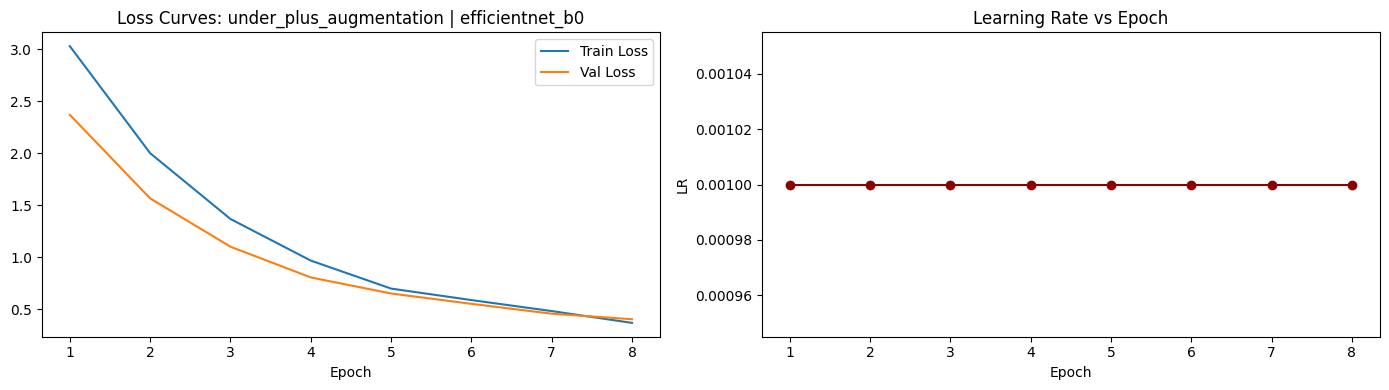

In [ ]:
if len(results) > 0:
    best_row = results_df.sort_values('f1_score', ascending=False).iloc[0]
    best_key = (best_row['setting'], best_row['model'])
    hist = artifacts[best_key]['history']

    epochs_axis = np.arange(1, len(hist['train_loss']) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    axes[0].plot(epochs_axis, hist['train_loss'], label='Train Loss')
    axes[0].plot(epochs_axis, hist['val_loss'], label='Val Loss')
    axes[0].set_title(f'Loss Curves: {best_key[0]} | {best_key[1]}')
    axes[0].set_xlabel('Epoch')
    axes[0].legend()

    axes[1].plot(epochs_axis, hist['lr'], marker='o', color='darkred')
    axes[1].set_title('Learning Rate vs Epoch')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('LR')

    plt.tight_layout()
    plt.show()
else:
    print('No history to plot yet.')

## 10. Confusion Matrix (Task 7 Deliverable)

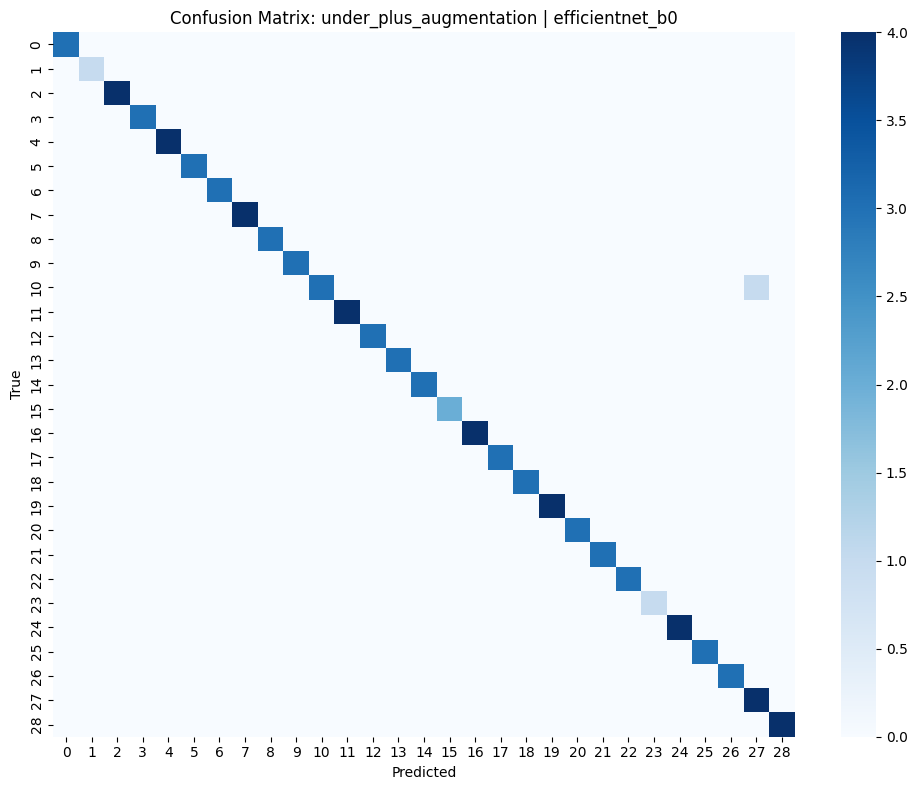

In [ ]:
if len(results) > 0:
    best_row = results_df.sort_values('f1_score', ascending=False).iloc[0]
    best_key = (best_row['setting'], best_row['model'])
    cm = artifacts[best_key]['cm']

    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, cmap='Blues')
    plt.title(f'Confusion Matrix: {best_key[0]} | {best_key[1]}')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.tight_layout()
    plt.show()
else:
    print('No confusion matrix yet.')

## 11. Short Analysis (Task 7 deliverable template)
1. Compare all three data settings using the result table (focus on weighted F1).
2. Identify whether under-sampling improved minority-class behavior vs baseline.
3. Check whether under+augmentation gives better recall without hurting precision too much.
4. Compare EfficientNet-B0, MobileNetV3, and ConvNeXt-Tiny under the same setting.
5. Use confusion matrix to identify classes still confused frequently.
6. Relate LR decay points to validation-loss plateau regions.
7. Mention best model + best setting and justify with metrics.
8. Mention one limitation and one improvement idea (for example, stronger augmentations or focal loss).